In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from multiprocessing import Process, Queue, Pool
import emcee
from astropy.cosmology import FlatLambdaCDM
from astropy import units as u
import warnings
import sys
warnings.filterwarnings("ignore")

import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rc('font', size=24)

In [2]:
#Helper function for our escape library
def cosmology(cosmology):
    case = cosmology.name
    if case == 'Flatw0waCDM':
        return [cosmology.Om0, cosmology.w0, cosmology.wa, cosmology.h]
    
    elif case == 'FlatwCDM':
        return [cosmology.Om0, cosmology.w0, cosmology.h]

    elif case == 'wCDM':
        return [cosmology.Om0, cosmology.Ode0, cosmology.w0,cosmology.h]
        
    elif case == 'LambdaCDM':
        return [cosmology.Om0, cosmology.Ode0, cosmology.h]

    elif case == 'FlatLambdaCDM':
        return [cosmology.Om0, cosmology.h]


In [3]:
#please rename these for your file paths
path_to_function_libraries = "/your_path_to/Escape_Library/Function_Libraries/"
path_to_galaxy_data = "/your_path_to/Escape_Library/Data/"
path_to_Zv_calibration='/your_path_to/Escape_Library/AGAMA_Zv_calibration'
savefig_path = '/your_path_to/Escape_Library/Savefigs'

if path_to_function_libraries not in sys.path:
    sys.path.insert(0, path_to_function_libraries)
    
from escape_analysis_functions import MassEstimator_two_stage

Omega_m = 0.3
Omega_L = 1-Omega_m
h0 = 0.7

cosmo_name = 'FlatLambdaCDM'
cosmo = FlatLambdaCDM(H0=h0*100.0,Om0=Omega_m,name = cosmo_name)
cosmo_params = cosmology(cosmo)

In this example we assume the cluster we observe is A7. We use Rines 2013 and 2016 HeCS and HeCS-SZ data, and a "tiebreak" Mass estimate from lensing from Herbonnet 2020, corresponding to $M_{200} = 10^{14.64}\, M_{\odot}$. This tiebreak mass is only used in the pipeline if the mass posterior in the pilot run is highly non-Gaussian. In the subsequent cell, we show an example for the same cluster, except when no "tiebreak" mass is used.


Running pilot MCMC...


100%|██████████| 100/100 [01:40<00:00,  1.01s/it]


mean acceptance: 0.603
log10 M200 = 14.775 (+0.131 / -0.124) dex


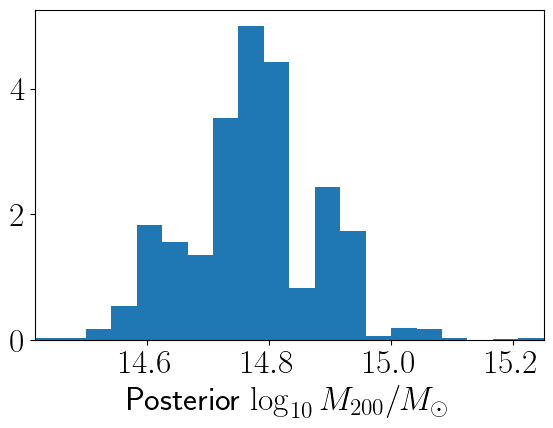

Escape Velocity Mass Estimate: 14.77 + 0.13 - 0.13
Densest peak estimate: 14.773222607179601
Reason: {'reason': 'escape_mass_dominant'}
Running main MCMC...


100%|██████████| 100/100 [00:12<00:00,  8.15it/s]


mean acceptance: 0.767
log10 M200 = 14.808 (+0.085 / -0.071) dex


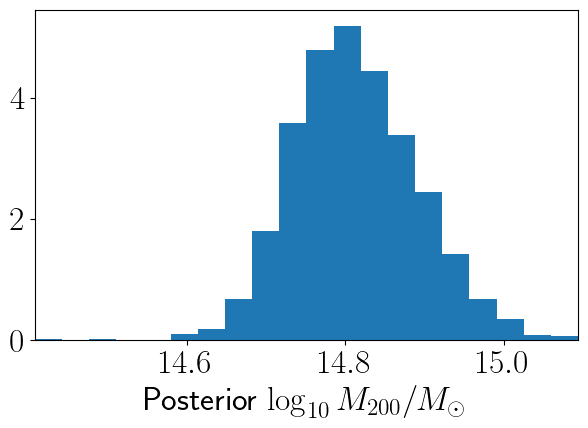

Escape Velocity Mass Estimate: 14.81 + 0.08 - 0.07

[post] Saved figure to: /nfs/turbo/lsa-christoq/Christoq1/alexcrod/Escape_Analysis/Data/Phase_Spaces/Herbonnet/A7.pdf


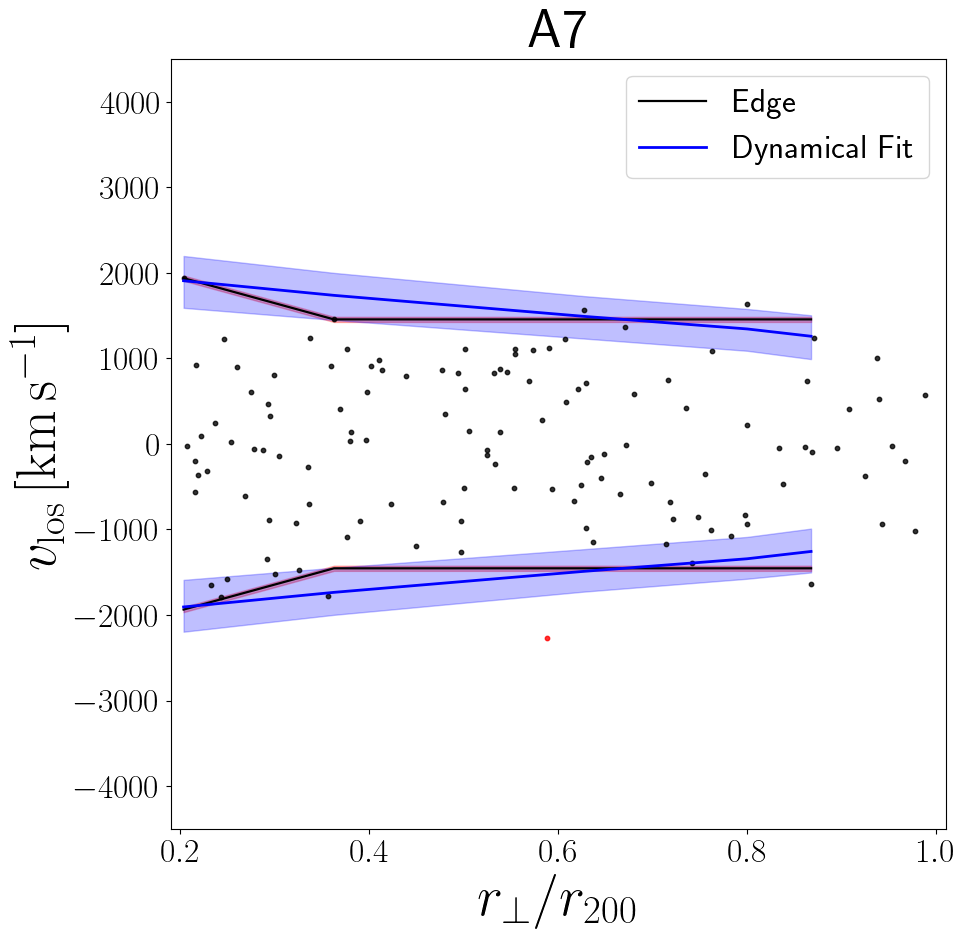

In [4]:
cluster_name = 'A7'
galaxy_positional_data = np.genfromtxt(os.path.join(path_to_galaxy_data, 'Rines_galaxy_data.txt'))

#This is the cluster position in RA, DEC, and z
cluster_positional_data = (2.93854167, 32.41569444, 0.106)
M200_init = 14.64345268 # Weak lensing M200 from Herbonnet 2020 (must be in log solar masses). Used in pilot run to converge to aperture

vesc_error_floor_use = 30 # error on velocities, in km/s
coremin_cut = 0.44
cut = 4500
NON_INC = True

results = MassEstimator_two_stage(
   path_to_Zv_calibration = path_to_Zv_calibration,
   cluster_positional_data = cluster_positional_data,
   galaxy_positional_data = galaxy_positional_data,
   cluster_name = cluster_name,
   M200_estimate = M200_init,
   cosmo_params = cosmo_params,
   cosmo_name = cosmo_name,
   vesc_error_floor = vesc_error_floor_use,
   savefig_path = savefig_path,
   NON_INC = NON_INC,
   cut = cut,
   coremin_cut = coremin_cut,
   nwalkers_pilot=nwalkers_pilot,
   nsteps_pilot=nsteps_pilot,
   nwalkers_data=nwalkers_data,  
   nsteps_data=nsteps_data)


Running pilot MCMC...


100%|██████████| 100/100 [01:41<00:00,  1.01s/it]

mean acceptance: 0.556
log10 M200 = 14.791 (+0.123 / -0.101) dex


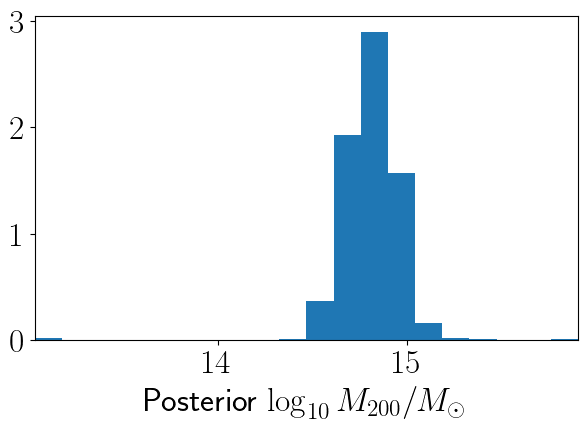

Escape Velocity Mass Estimate: 14.79 + 0.12 - 0.1
Densest peak estimate: 14.784176993966103
Reason: {'reason': 'escape_mass_dominant'}
Running main MCMC...


100%|██████████| 100/100 [00:13<00:00,  7.51it/s]


mean acceptance: 0.768
log10 M200 = 14.715 (+0.089 / -0.073) dex


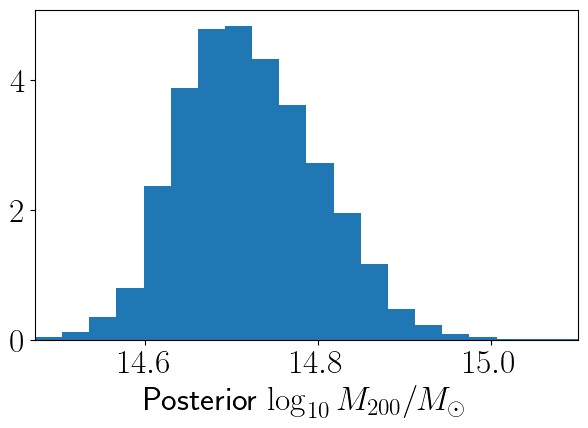

Escape Velocity Mass Estimate: 14.71 + 0.09 - 0.07

[post] Saved figure to: /nfs/turbo/lsa-christoq/Christoq1/alexcrod/Escape_Analysis/Data/Phase_Spaces/Herbonnet/A7.pdf


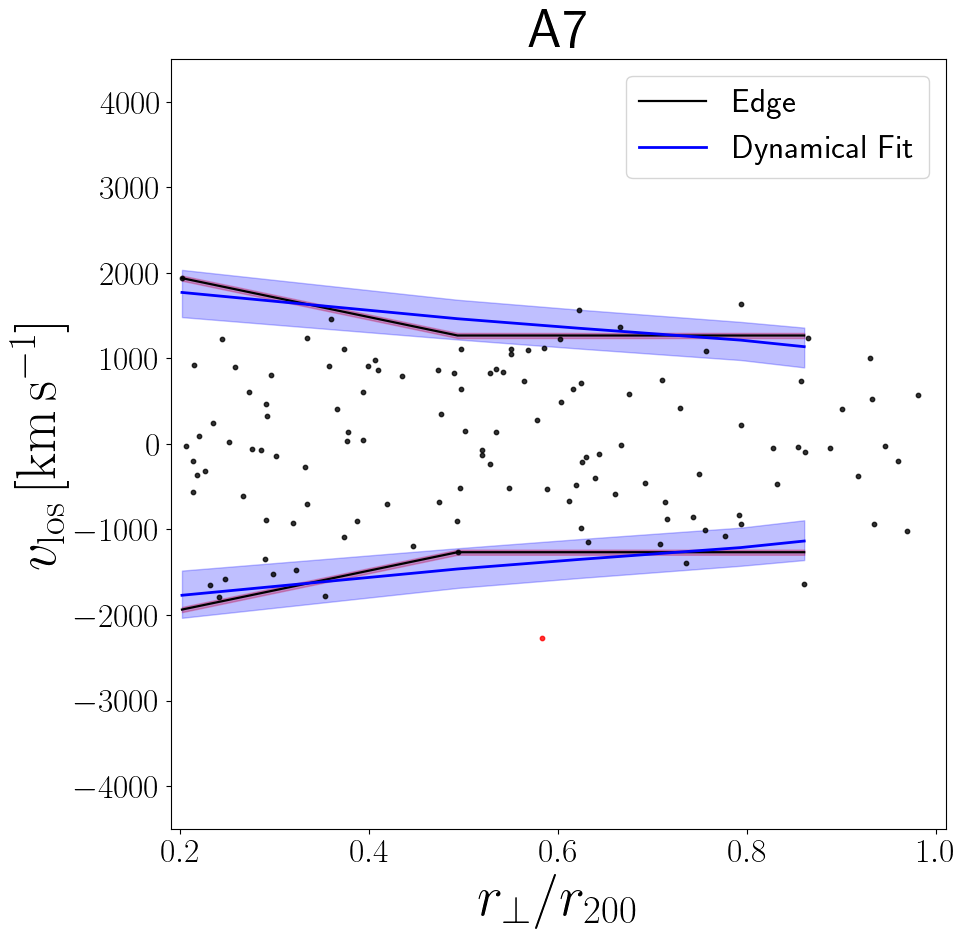

In [5]:
#Same as above, but no initial M200 Guess

results = MassEstimator_two_stage(
   path_to_Zv_calibration = path_to_Zv_calibration,
   cluster_positional_data = cluster_positional_data,
   galaxy_positional_data = galaxy_positional_data,
   cluster_name = cluster_name,
   M200_estimate = None,
   cosmo_params = cosmo_params,
   cosmo_name = cosmo_name,
   vesc_error_floor = vesc_error_floor_use,
   savefig_path = savefig_path,
   NON_INC = NON_INC,
   cut = cut,
   coremin_cut = coremin_cut,
   nwalkers_pilot=nwalkers_pilot,
   nsteps_pilot=nsteps_pilot,
   nwalkers_data=nwalkers_data,  
   nsteps_data=nsteps_data)
